시각화 관련 공통 라이브러리를 불러온다.
(공통 라이브러리에 대한 설명은 code_reference/README.md 파일을 참조)

In [1]:
# 코랩 환경 등 깃허브 전체를 clone해서 실습하는 경우가 아니라면 
# 공통 라이브러리를 불러오기 위해서 별도의 과정이 필요하므로 code_reference/README.md 파일을 확인하자.

import sys
sys.path.append('../../')

from code_reference import visualize as viz
# 시각화 결과를 파일에 저장하지 않음
viz.configure(save_grayscale=False)

- 다음 셀은 결과 재현성을 보장하기 위해서 시드를 고정한다. 
- 시드값에 따라 파라미터 초기값이 달라져 결과가 달라질 수 있다.
- 여기서 지정하는 시드값 8은 저자의 환경에서 본문과 같은 결과가 나오는 시드값으로, 같은 시드값을 사용하더라도 각자 실습 환경에 따라 결과가 달라질 수 있다.

In [2]:
import random

import numpy as np
import torch

SEED = 8
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# 1-3 첫 번째 딥러닝 모델

본 노트북은 본문 1-3절의 코드 예제와 관련 내용을 다룬다. 주요 내용은 다음과 같다.
- 외계 행성 자유 낙하 데이터 생성
- 모델 함수, 손실 함수 정의
- 학습 루프와 평가 과정(학습 곡선 시각화 포함)

본문의 모델 1의 구현에 해당되며, 모델 1의 설명은 다음과 같다.

> **모델 1. 외계 행성의 물리 법칙 검증 모델**
>
> 기술이 크게 발전한 인류는 지구와 모든 면에서 비슷한 외계 행성을 발견했다. 이주 가능 여부를 확인하려고 파견된 탐사대의 임무에는, 갈릴레오가 발견하고 뉴턴이 법칙으로 정리한 다음 공식이 외계 행성에서도 성립하는지 확인하는 실험이 들어 있었다.
>
> $$\text{낙하거리} = \frac{1}{2} \times \text{중력가속도} \times \text{낙하시간}^2$$
>
> 탐사대는 임의의 높이에서 물체를 50번 떨어뜨려 낙하시간을 측정한 후 지구로 데이터를 보내왔다. 지구의 분석팀은 이 데이터를 바탕으로 이 행성에서도 지구와 같은 물리 법칙이 성립하는지 확인해야 한다.

- 다만 실제로 발생한 상황은 아니므로, 모델 1의 데이터는 그럴싸한 데이터를 생성해 사용한다.

## 회귀 분석 딥러닝 모델의 설계

### 모델 함수

- 뉴턴의 법칙에 따라 낙하 거리는 낙하 시간의 제곱에 비례
- 회귀 분석 모델: $y = a x^{2} + b$로 정의
- 학습 파라미터: $a$, $b$ → 두 값을 묶어 `(2,)` 형테의 텐서 `parameters`로 정의

In [3]:
########################################################################################
# 코드 1-28 - 함수의 형태로 정의한 회귀 분석 모델
########################################################################################

# 주어진 파라미터 텐서(parameters)와 낙하 시간의 텐서(X)로 낙하 거리를 계산하는 함수
def model(parameters, X):
    return parameters[0] * X ** 2 + parameters[1]

### 손실 함수
- `(정답, 예측)`의 쌍이 `(19, 20)`과 `(21, 20)`인 두 데이터는 오차(1과 -1)를 단순 평균으로 집계해 손실로 사용하면 오차가 사라짐
- 이런 문제를 해결하기 위해 회귀 분석에서 자주 사용하는 평균제곱오차(MSE) 손실 함수 사용

In [4]:
########################################################################################
# 코드 1-29 - 평균제곱오차 손실 함수
########################################################################################

import torch

# 회귀 분석에 주로 사용되는 평균제곱오차 손실 함수
def criterion(Y_pred, Y_true):
    return torch.mean((Y_pred - Y_true) ** 2)

Y_pred = torch.tensor([20., 20.])                 # 샘플 2건의 모델 예측값 텐서
Y_true = torch.tensor([19., 21.])                 # 샘플 2건의 관측값(실제값) 텐서
loss = criterion(Y_pred, Y_true)                  # 평균제곱오차 손실 계산
print(f'계산된 손실값: {loss.item()}')            

계산된 손실값: 1.0


### 데이터 준비

- 외계 행성 탑사대가 보내왔을 것 같은 그럴싸한 데이터를 생성
- 데이터 생성 과정
    1. 관측시간 $x$로 낙하거리($4.9x^{2}$)를 계산 
    2. 표준정규분포 난수에 낙하거리의 10%를 곱해 관측 오차를 흉내내는 노이즈를 생성
    3. 낙하거리에 노이즈를 더한 값을 관측거리로 사용

In [5]:
# 참고 - 가상의 관측 데이터 생성

SAMPLE_SIZE = 50                            # 생성할 샘플의 수
# y = 1/2gx² 기준의 실제 물리량 (지구 기준)
TRUE_A = 4.9                                # TRUE_A: 중력 가속도(g) 9.8의 절반
TRUE_B = 0.0                                # TRUE_B: 초기 낙하거리 (0으로 고정)

# 낙하거리 모델이 계산한 이상적인 값에 관측 오차를 더해서 가상의 관측 데이터를 생성하는 함수
def generate_true_data(true_a=TRUE_A, true_b=TRUE_B, sample_size=SAMPLE_SIZE):
    X = torch.rand((sample_size, 1)) * 10   # 관측시간(X) 무작위 생성
    Y_ideal = true_a * X ** 2 + true_b      # 이상적인 낙하거리 계산
    # 평균 0, 표준편차 Y_ideal * 0.1의 정규분포에서 무작위 노이즈 생성 (관측 오차)
    noise = torch.randn((sample_size, 1)) * Y_ideal * 0.1  
    Y_true = Y_ideal + noise                # 관측 낙하거리 (Y_true)
    return X, Y_true

X, Y_true = generate_true_data()            # 가상의 관측 데이터 생성

print(f'X 형태: {X.shape}, Y_true 형태: {Y_true.shape}')
print(f'첫 5개 (관측시간, 관측거리) 쌍:')
for i in range(5):
    print(f'  관측시간: {X[i, 0]:.4f}, 관측거리: {Y_true[i, 0]:.4f}')

X 형태: torch.Size([50, 1]), Y_true 형태: torch.Size([50, 1])
첫 5개 (관측시간, 관측거리) 쌍:
  관측시간: 5.9793, 관측거리: 193.2014
  관측시간: 8.4530, 관측거리: 395.0081
  관측시간: 9.4641, 관측거리: 392.5826
  관측시간: 2.9653, 관측거리: 49.5448
  관측시간: 5.1380, 관측거리: 142.4538


- 생성한 가상 관측 데이터의 산포도 그래프([그림 1-10])
    - 주황색 곡선: 이상적인 기준선($y = 4.9 x^{2}$)
    - 점: 노이즈가 섞인 실제 관측 데이터(관측 시간이 커질수록 노이즈의 크기도 함께 커짐)
- 그래프를 시각화하는 `plot_regression_scatter()`는 공통 라이브러리 문서 참조

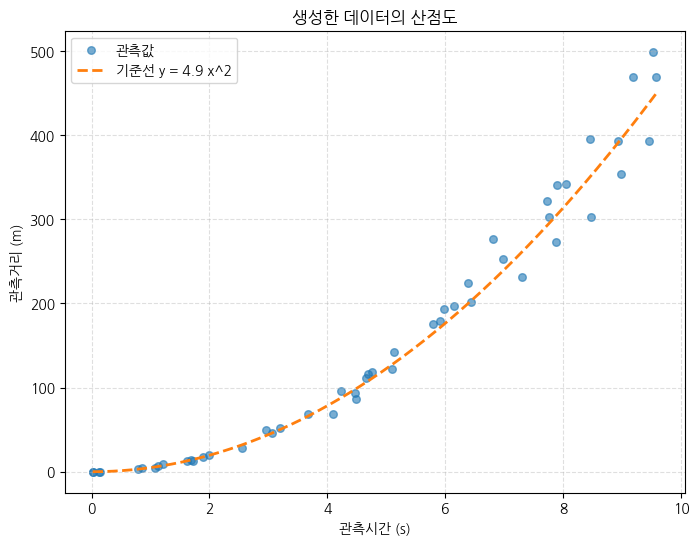

In [6]:
# 참고 - 생성한 데이터의 산점도와 이상적 기준선 ([그림 1-10])
viz.plot_regression_scatter(
    X, Y_true,
    reference_fn=lambda x: TRUE_A * x ** 2 + TRUE_B,
    reference_label='기준선 y = 4.9 x^2',
    title='생성한 데이터의 산점도',
    x_label='관측시간 (s)',
    y_label='관측거리 (m)',
)

### 훈련/평가 데이터 분리
- 생성한 50 샘플 데이터를 분리
    - 훈련 데이터(40 샘플): 모델 학습에 사용
    - 평가 데이터(10 샘플): 모델 평가에 사용

In [7]:
########################################################################################
# 코드 1-30 - 훈련 데이터와 평가 데이터 분리
########################################################################################

TRAINS_SIZE = int(SAMPLE_SIZE * 0.8)     # 훈련 데이터의 개수 (전체 샘플의 80%)

# 훈련 데이터와 평가 데이터를 4:1 비율로 분리
X_train, Y_train = X[:TRAINS_SIZE], Y_true[:TRAINS_SIZE]
X_test, Y_test = X[TRAINS_SIZE:], Y_true[TRAINS_SIZE:]

print(f'훈련 데이터: X_train {X_train.shape}, Y_train {Y_train.shape}')
print(f'평가 데이터: X_test  {X_test.shape}, Y_test  {Y_test.shape}')

훈련 데이터: X_train torch.Size([40, 1]), Y_train torch.Size([40, 1])
평가 데이터: X_test  torch.Size([10, 1]), Y_test  torch.Size([10, 1])


### 회귀 분석 모델의 구현

#### 파라미터 초기화

- 학습 대상인 `parameters` 텐서(`(2,)` 형태)를 자동 미분 대상으로 초기화

In [8]:
########################################################################################
# 코드 1-31 - 모델 파라미터 텐서와 학습 하이퍼파라미터
########################################################################################

# 모델 파라미터: [a, b] 에 해당하는 (2, ) 텐서를 자동 미분 대상으로 지정해 생성
parameters = torch.randn((2, ), requires_grad=True)

print(f'파라미터 초기값: a={parameters[0]:.4f}, b={parameters[1]:.4f}')

파라미터 초기값: a=0.9642, b=-0.5650


#### 학습 하이퍼파라미터
- 하이퍼파라미터
    - 모델 학습의 환경 변수 역할을 하며, 모델의 구조와 학습 과정 등을 결정
    - 학습 전에 미리 정해야 하는 값으로, 반복 실험을 통한 시행 착오를 거쳐 최적의 값을 찾아야 함
    - 상수의 성격으로 변수 이름도 대문자를 쓰는 관례를 따름
- `LR`(학습률): 파라미터를 최적화 할 때 손실을 얼마나 반영할지 결정하는 비율
- `EPOCHS`(전체 학습 에포크): 전체 훈련 데이터를 반복 사용하는 횟수


In [9]:
########################################################################################
# 코드 1-31 - 모델 파라미터 텐서와 학습 하이퍼파라미터(계속)
########################################################################################

# 학습 하이퍼파라미터
LR = 0.0001                  # 학습률: 최적화에 오차를 반영하는 비율
EPOCHS = 15                  # 전체 학습 에포크: 전체 훈련 데이터를 반복 사용하는 횟수

#### 학습 루프

- 1 에포크(1번의 학습 루프)는 다음과 같이 다섯 단계로 구성
    1.	기울기 초기화: 이전 자동 미분 결과가 누적되지 않도록 기울기의 값(parameters.grad)을 초기화
    2.	순전파: 현재 파라미터(parameters)로 예측값(Y_pred)을 계산
    3.	손실 계산: 손실 함수로 정답(Y_true)과 예측값(Y_pred) 사이의 오차를 집계해 손실을 계산
    4.	역전파: backward()로 파라미터의 기울기(parameters.grad)를 계산
    5.	최적화: 파라미터 값에서 기울기 x 학습률을 뺀 값으로 갱신

In [10]:
########################################################################################
# 코드 1-32 - 학습 루프 함수 train()
########################################################################################

# model을 epochs회 반복해 최적화하는 학습 루프 함수
def train(model, criterion, parameters, X, Y_true, epochs=EPOCHS, learning_rate=LR):    
    for epoch in range(1, epochs + 1):
        parameters.grad = None                                # 1. 기울기 초기화
        Y_pred = model(parameters, X)                         # 2. 순전파: 모델 예측값 계산
        train_loss = criterion(Y_pred, Y_true)                # 3. 손실 계산
        train_loss.backward()                                 # 4. 역전파: 기울기 계산
        # 연산 그래프를 생성하지 않는 컨텍스트 블록
        with torch.no_grad():
            # 5. 최적화: 파라미터를 자동 미분 결과에 학습률을 곱한 값만큼 차감(복합 할당 연산 사용)
            parameters -= learning_rate * parameters.grad     # 최적화
        # 에포크마다 학습 로그 출력
        print(
            f'에포크 [{(epoch):2d}/{epochs}], '
            f'손실(평균제곱오차): {train_loss.item():.2f}, '
            f'파라미터 값: {parameters[0]:.2f}, {parameters[1]:.2f}'
        )

### 모델 학습과 평가

#### 모델 학습

In [11]:
########################################################################################
# 코드 1-33 - 모델의 학습 과정
########################################################################################

# 비교를 위해 파라미터 초깃값 출력
print(f'파라미터의 초깃값: {parameters[0]:.2f}, {parameters[1]:.2f}')
# 모델 학습
train(model, criterion, parameters, X_train, Y_train, EPOCHS, LR)

파라미터의 초깃값: 0.96, -0.56
에포크 [ 1/15], 손실(평균제곱오차): 29229.98, 파라미터 값: 2.35, -0.54
에포크 [ 2/15], 손실(평균제곱오차): 13227.29, 파라미터 값: 3.27, -0.52
에포크 [ 3/15], 손실(평균제곱오차): 6101.10, 파라미터 값: 3.89, -0.51
에포크 [ 4/15], 손실(평균제곱오차): 2927.71, 파라미터 값: 4.30, -0.51
에포크 [ 5/15], 손실(평균제곱오차): 1514.56, 파라미터 값: 4.58, -0.50
에포크 [ 6/15], 손실(평균제곱오차): 885.27, 파라미터 값: 4.76, -0.50
에포크 [ 7/15], 손실(평균제곱오차): 605.03, 파라미터 값: 4.88, -0.50
에포크 [ 8/15], 손실(평균제곱오차): 480.24, 파라미터 값: 4.96, -0.50
에포크 [ 9/15], 손실(평균제곱오차): 424.67, 파라미터 값: 5.02, -0.49
에포크 [10/15], 손실(평균제곱오차): 399.92, 파라미터 값: 5.06, -0.49
에포크 [11/15], 손실(평균제곱오차): 388.90, 파라미터 값: 5.08, -0.49
에포크 [12/15], 손실(평균제곱오차): 384.00, 파라미터 값: 5.10, -0.49
에포크 [13/15], 손실(평균제곱오차): 381.81, 파라미터 값: 5.11, -0.49
에포크 [14/15], 손실(평균제곱오차): 380.84, 파라미터 값: 5.11, -0.49
에포크 [15/15], 손실(평균제곱오차): 380.41, 파라미터 값: 5.12, -0.49


#### 모델 평가
- 학습이 끝난 모델(파라미터)를 인자로 전달해 모델 함수를 호출하면 모델 예측 결과를 구할 수 있음
- 평가 데이터셋의 예측 결과로 계산한 손실을 사용해 모델을 평가한다
    - 모델 평가는 최적화와 무관한 과정이므로, `torch.no_grad()` 컨텍스트를 사용해 연산 그래프를 만들지 않는다.


In [12]:
########################################################################################
# 코드 1-34 - 모델의 평가
########################################################################################
    
# 평가 데이터를 사용해 예측: 최적화와 무관하므로 no_grad() 컨텍스트 사용
with torch.no_grad():
    Y_pred_test = model(parameters, X_test)
    # 평가 데이터로 손실(평균제곱오차) 계산
    test_loss = criterion(Y_pred_test, Y_test)

print(f'평가 데이터로 구한 손실: {test_loss:.4f}') 

평가 데이터로 구한 손실: 805.2178


#### 참고 - 모델 예측과 이상적인 기준선 비교 시각화 
- 주황색 점선: 이상적인 기준선($y = 4.9 x^{2}$)
- 붉은 실선: 학습 후의 모델 파라미터 $a$, $b$로 그린 모델 예측선($y = ax^{2}+b$)
- 파란 점: 평가 데이터 10건의 관측값. 붉은 삼각형은 같은 관측시간에 대한 모델의 예측값이며, 두 점을 잇는 회색 선의 길이가 오차에 해당

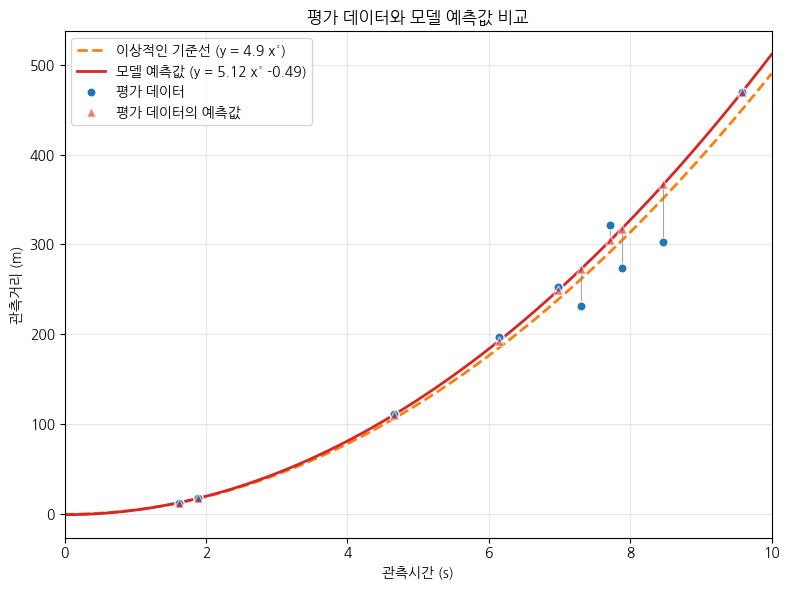

In [13]:
# 참고 - 평가 데이터와 모델 예측값 비교

import matplotlib.pyplot as plt
from code_reference.common import set_korean_plot_env

set_korean_plot_env()

# 곡선을 그릴 x 좌표 (관측시간 0초부터 10초까지)
x_line = torch.linspace(0, 10, 200).unsqueeze(1)

# 학습이 끝난 파라미터로 계산한 모델 예측값
with torch.no_grad():
    y_pred_line = model(parameters, x_line)

# 데이터를 만들 때 사용한 이상적인 기준선
y_ideal_line = TRUE_A * x_line ** 2 + TRUE_B

fig, ax = plt.subplots(figsize=(8, 6))

# 이상적인 기준선
ax.plot(
    x_line, y_ideal_line,
    color='tab:orange', linestyle='--', linewidth=2,
    label=f'이상적인 기준선 (y = {TRUE_A} x²)',
)

# 학습한 모델의 예측값 곡선
ax.plot(
    x_line, y_pred_line,
    color='tab:red', linewidth=2,
    label=f'모델 예측값 (y = {parameters[0]:.2f} x² {parameters[1]:+.2f})',
)

# 평가 데이터의 관측값과 예측값을 잇는 선으로 오차 표시
for x, y_obs, y_hat in zip(X_test, Y_test, Y_pred_test):
    ax.plot([x, x], [y_obs, y_hat], color='gray', linewidth=0.8, alpha=0.7, zorder=2)

# 평가 데이터
ax.scatter(
    X_test, Y_test,
    s=45, color='tab:blue', edgecolor='white', zorder=3, label='평가 데이터',
)
ax.scatter(
    X_test, Y_pred_test,
    s=45, marker='^', color='tab:red', alpha=0.6, edgecolor='white', zorder=3,
    label='평가 데이터의 예측값',
)

ax.set_title('평가 데이터와 모델 예측값 비교')
ax.set_xlabel('관측시간 (s)')
ax.set_ylabel('관측거리 (m)')
ax.set_xlim(0, 10)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

### 과적합 여부의 확인

- 매 에포크의 훈련 손실과 평가 손실을 함께 기록한 학습 곡선([그림 1-11])
- 이를 위해서 학습 과정에 매 에포크마다 평가 데이터의 손실을 계산하도록 학습 루프를 수정해 모델을 재학습한다.

In [14]:
# 참고 - 학습 곡선([그림 1-11]) 시각화를 위한 모델 재학습 및 손실 기록

# 파라미터를 동일한 초기값으로 재설정하기 위해 시드를 다시 고정한 뒤 새로 생성, 학습한다.
random.seed(8)
np.random.seed(8)
torch.manual_seed(8)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(8)

X, Y_true = generate_true_data()
X_train, Y_train = X[:TRAINS_SIZE], Y_true[:TRAINS_SIZE]
X_test, Y_test = X[TRAINS_SIZE:], Y_true[TRAINS_SIZE:]

parameters = torch.randn((2, ), requires_grad=True)

train_losses = []
test_losses = []
for epoch in range(EPOCHS):
    parameters.grad = None
    Y_pred = model(parameters, X_train)
    train_loss = criterion(Y_train, Y_pred)
    train_loss.backward()

    with torch.no_grad():
        parameters -= LR * parameters.grad
        # 평가 손실 - 파라미터 갱신 후 시점
        Y_pred_test = model(parameters, X_test)
        test_loss = criterion(Y_test, Y_pred_test)

    train_losses.append(train_loss.item())
    test_losses.append(test_loss.item())

print(f'최종 훈련 손실: {train_losses[-1]:.4f}')

최종 훈련 손실: 380.4051


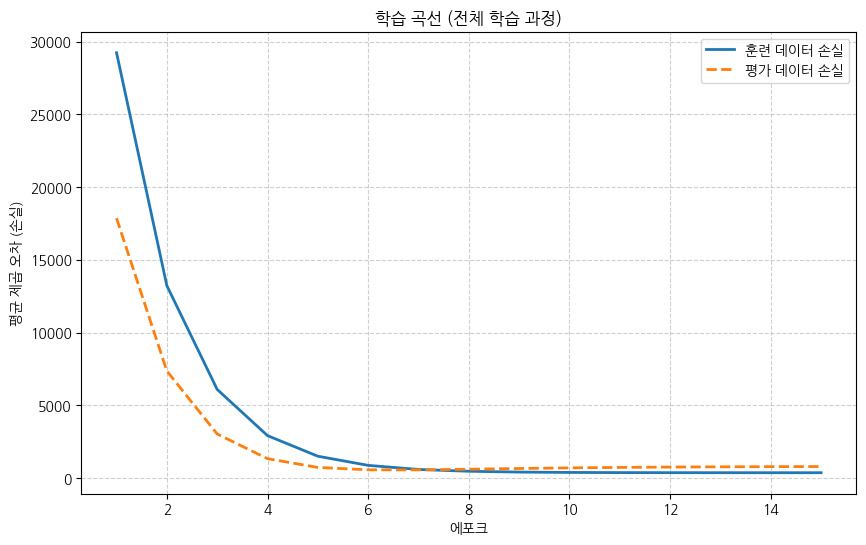

In [15]:
# 참고 - 학습 곡선 시각화 ([그림 1-11])
viz.plot_histories(
    {'훈련 데이터 손실': train_losses, '평가 데이터 손실': test_losses},
    title='학습 곡선 (전체 학습 과정)',
    x_label='에포크',
    y_label='평균 제곱 오차 (손실)',
    figsize=(10, 6),
)

- 세부 변화 양상을 확인하기 위해서 5 에포크 이후 구간만 따로 확대 ([그림 1-12])

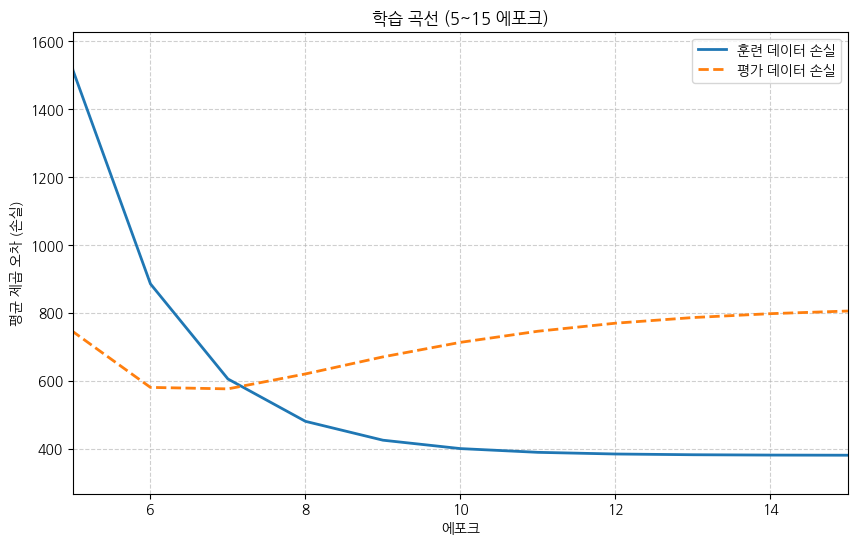

평가 손실 최저 - 에포크 7, 평가 손실 575.8670


In [16]:
# 참고 - 학습 곡선의 5 에포크 이후 확대 ([그림 1-12])

tail = train_losses[4:] + test_losses[4:]          # 5 에포크 이후 두 손실
margin = (max(tail) - min(tail)) * 0.1
y_lo, y_hi = min(tail) - margin, max(tail) + margin

viz.plot_histories(
    {'훈련 데이터 손실': train_losses, '평가 데이터 손실': test_losses},
    title='학습 곡선 (5~15 에포크)',
    x_label='에포크', y_label='평균 제곱 오차 (손실)',
    x_lim=(5, EPOCHS),
    y_lim=(y_lo, y_hi),
    figsize=(10, 6),
)

# 평가 손실이 최저였던 에포크 확인
best_epoch = int(np.argmin(test_losses)) + 1
print(
    f'평가 손실 최저 - 에포크 {best_epoch}, '
    f'평가 손실 {min(test_losses):.4f}'
)